# Risultati finali — la matrice a 900 run

Questo notebook espone i risultati sperimentali della tesi *Neuro-Symbolic PPM with
Procedural Background Knowledge*. Non allena nulla: legge la tabella prodotta da
`scripts/final_matrix.py` e la interroga.

**La domanda.** Dare a un modello di next-activity prediction la conoscenza procedurale
del processo — il DFG dei vincoli, il marking di una Petri net, la struttura del grafo,
la storia degli stati — lo rende migliore? E *in che senso* migliore: più accurato, o più
conforme al processo?

**Il disegno.** Ogni cella della matrice è un modello allenato e valutato:

$$3 \text{ dataset} \times 2 \text{ architetture} \times 5 \text{ varianti} \times
3 \text{ livelli di noise} \times 10 \text{ seed} = 900 \text{ run}$$

Le varianti formano una **scala di ablazione**: ogni gradino aggiunge *una cosa sola* al
precedente. È questo che permette di leggere un delta come l'effetto di quell'ingrediente
e non di un cambio confuso di tre cose insieme.

**Le fonti dei concetti usati qui**

| | |
|---|---|
| protocollo di valutazione (prefix log, split per case, next-activity) | Di Francescomarino, Donadello & Maggi, *Predictive Process Monitoring*, Springer 2026 — cap. 5 e 7 |
| logic loss su automi / conoscenza temporale in modelli sequenziali | Xie, Zhou & Soh, *Embedding Symbolic Temporal Knowledge into Deep Sequential Models*, arXiv:2101.11981 |
| marking della Petri net come feature, GNN sul grafo posti/transizioni | Rama-Maneiro, Vidal & Lama, *Embedding GCNs in RNNs for Predictive Monitoring* (TACO) |

## 1. I dati

Una riga = una run valutata sul test set. Le metriche sono quelle del capitolo 7 del libro
PPM, più le due di conformità che servono a questa tesi:

- `accuracy`, `macro_f1`, `top3` — **qualità predittiva**;
- `violation_rate` — quota di predizioni il cui **argmax** è un'attività vietata dal
  processo nello stato corrente;
- `forbidden` — massa di probabilità che il modello mette **complessivamente** sulle
  attività vietate. Guarda la distribuzione, non solo la scelta finale.

In [1]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src").exists():          # il notebook gira da notebooks/3_petrinets
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from nspm.visualization.architecture_plots import (
    plot_ablation_ladder, plot_variant_architecture,
)
from nspm.visualization.matrix_plots import (
    cell_means, load_matrix, metric_table, model_catalogue, plot_metric_by_noise,
    plot_paired_deltas, plot_winner_reliability, relative_change, winners,
)

pd.set_option("display.width", 200)

matrix = load_matrix(ROOT / "runs" / "final_matrix" / "results.csv")
print(f"{len(matrix)} run  |  {matrix['seed'].nunique()} seed  |  "
      f"{matrix['dataset'].nunique()} dataset  |  {matrix['noise'].nunique()} livelli di noise")
matrix.head()

900 run  |  10 seed  |  3 dataset  |  3 livelli di noise


,dataset,arch,variant,noise,seed,accuracy,macro_f1,top3,violation_rate,forbidden,best_epoch,corrupted
0,Sepsis_Case,gru,baseline,0.0,0,0.672997,0.493759,0.927744,0.0,0.002981,10,0
1,Sepsis_Case,gru,baseline,0.0,1,0.677165,0.488553,0.936082,0.0,0.002859,12,0
2,Sepsis_Case,gru,baseline,0.0,2,0.659565,0.472096,0.930987,0.0,0.003713,12,0
3,Sepsis_Case,gru,baseline,0.0,3,0.680871,0.493267,0.933302,0.0,0.002972,11,0
4,Sepsis_Case,gru,baseline,0.0,4,0.676702,0.492872,0.930523,0.0,0.002842,11,0


## 2. I dieci modelli

Una **configurazione** è una coppia (architettura, variante): 10 in tutto. Ognuna viene
allenata su ogni dataset, a ogni livello di noise, con ogni seed — 90 run a testa.

La colonna *entra come* è il perno di tutta la tesi. La stessa conoscenza di processo può
entrare nel modello in due modi radicalmente diversi:

- come **loss** (gradino 2): il modello resta identico, cambia solo cosa viene penalizzato
  durante il training — è la strategia di T-LEAF, qui in versione semantic-loss sul DFG;
- come **feature** (gradini 3-5): l'input viene arricchito con lo stato simbolico del
  processo — è la strategia di TACO.

I gradini 3, 4 e 5 sono tre livelli crescenti di sofisticazione della stessa idea:
**stato** → **stato + struttura** → **stato + struttura + tempo**.

In [2]:
model_catalogue(matrix)

,modello,architettura,gradino,conoscenza,entra come,descrizione,run,seed
0,gru,GRU,1 - baseline,nessuna,-,il modello puramente neurale di riferimento,90,10
1,gru_checker,GRU,2 - checker,DFG del processo,loss,penalizza la massa di probabilita' su attivita...,90,10
2,gru_marking,GRU,3 - marking,marking della Petri net,feature,"lo stato del replay, vettore piatto concatenat...",90,10
3,gru_gnn,GRU,4 - gnn,marking + struttura,feature,GNN eterogenea a 2 hop sul grafo posti/transiz...,90,10
4,gru_seq,GRU,5 - seq,marking + struttura + tempo,feature,"un marking per passo, GNN per passo + GRU interna",90,10
5,lstm,LSTM,1 - baseline,nessuna,-,il modello puramente neurale di riferimento,90,10
6,lstm_checker,LSTM,2 - checker,DFG del processo,loss,penalizza la massa di probabilita' su attivita...,90,10
7,lstm_marking,LSTM,3 - marking,marking della Petri net,feature,"lo stato del replay, vettore piatto concatenat...",90,10
8,lstm_gnn,LSTM,4 - gnn,marking + struttura,feature,GNN eterogenea a 2 hop sul grafo posti/transiz...,90,10
9,lstm_seq,LSTM,5 - seq,marking + struttura + tempo,feature,"un marking per passo, GNN per passo + GRU interna",90,10


### La struttura dei cinque gradini

Il diagramma sotto mostra i cinque modelli affiancati. Lo scheletro neurale — embedding,
RNN, testa di classificazione — è **identico ovunque** ed è disegnato in grigio; a colori
c'è solo ciò che il gradino aggiunge. I colori sono gli stessi che le varianti hanno nei
grafici dei risultati, così un modello si riconosce dal colore.

Due cose da guardare:

1. nei gradini **1 e 2** non entra niente accanto allo stato dell'RNN: la freccia lunga e
   vuota è il punto. Il `checker` cambia solo l'ultimo blocco, la loss — stessa
   architettura, stessi parametri, stesso numero di pesi della baseline;
2. nei gradini **3, 4 e 5** compare una seconda colonna che confluisce nella
   concatenazione. Cambia solo il blocco centrale: vettore grezzo → GNN sul grafo della
   rete → GNN per passo seguita da una GRU interna.

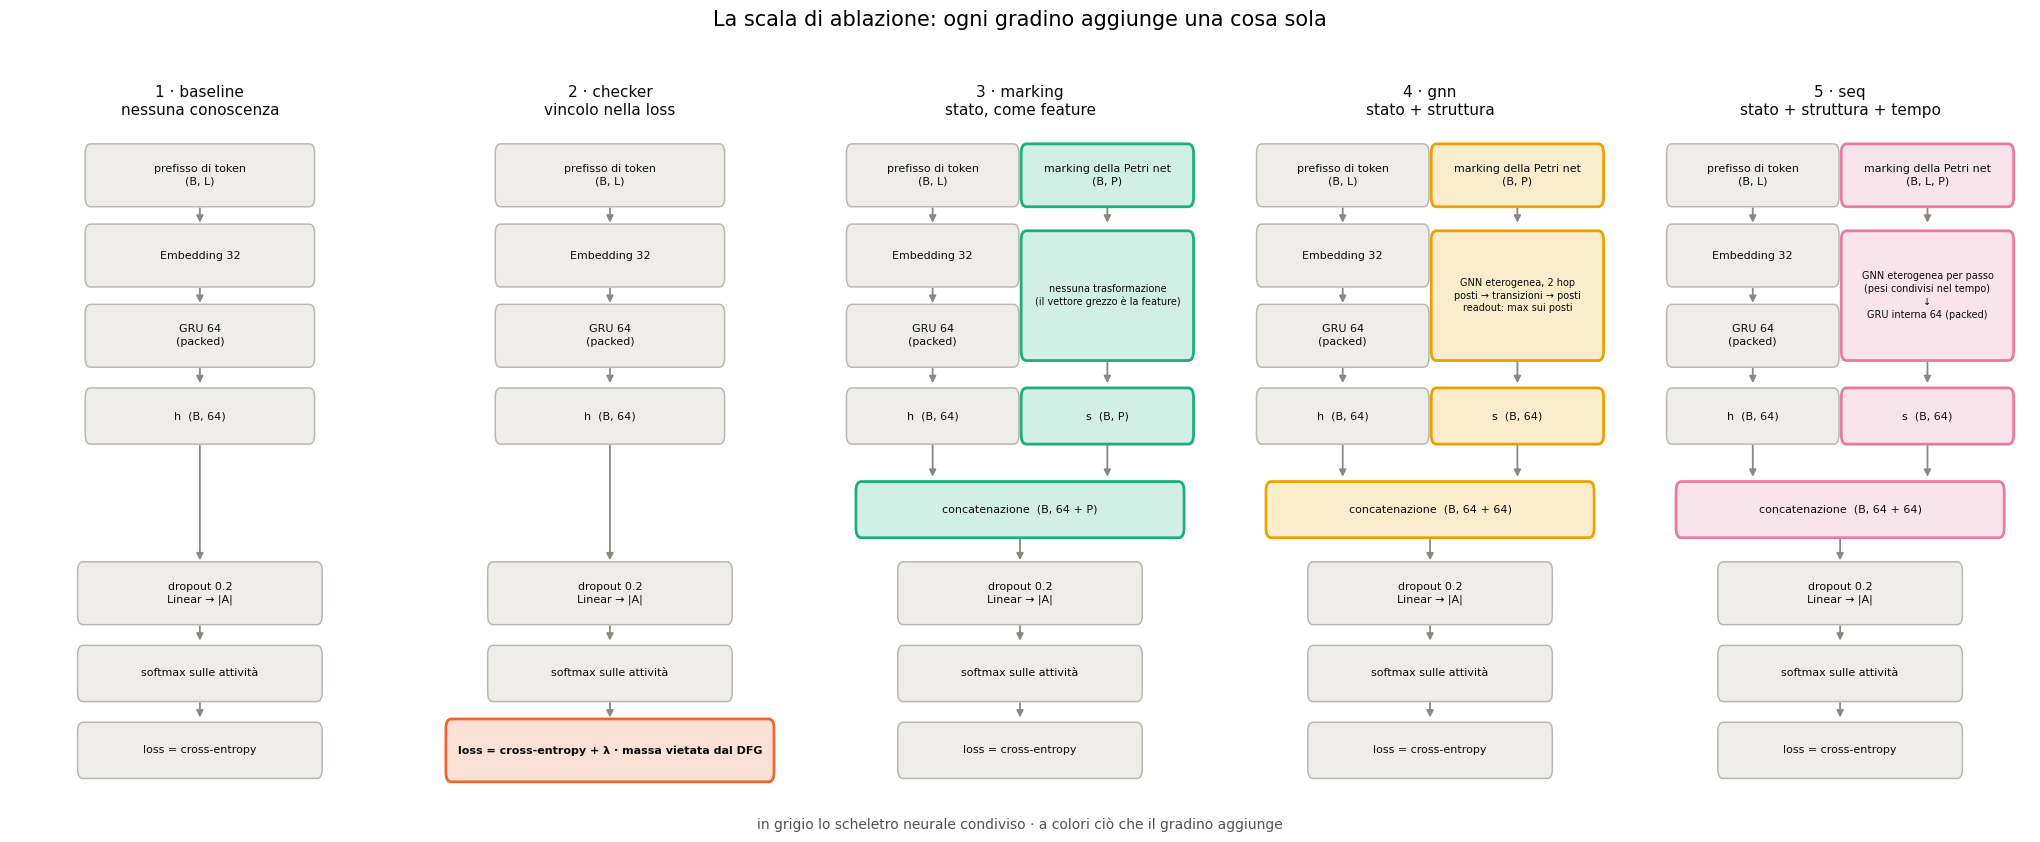

In [3]:
fig = plot_ablation_ladder()

Per una slide dedicata a un singolo modello, `plot_variant_architecture` disegna lo stesso
diagramma a piena pagina — qui il gradino 5, il più articolato: una GNN eterogenea viene
applicata al marking di **ogni passo** con gli stessi pesi, e la sequenza di vettori che ne
esce viene riassunta da una GRU interna. È la separazione spazio/tempo che TACO scarta a
favore della GRNN, scelta qui di proposito perché è il gradino misurabile successivo.

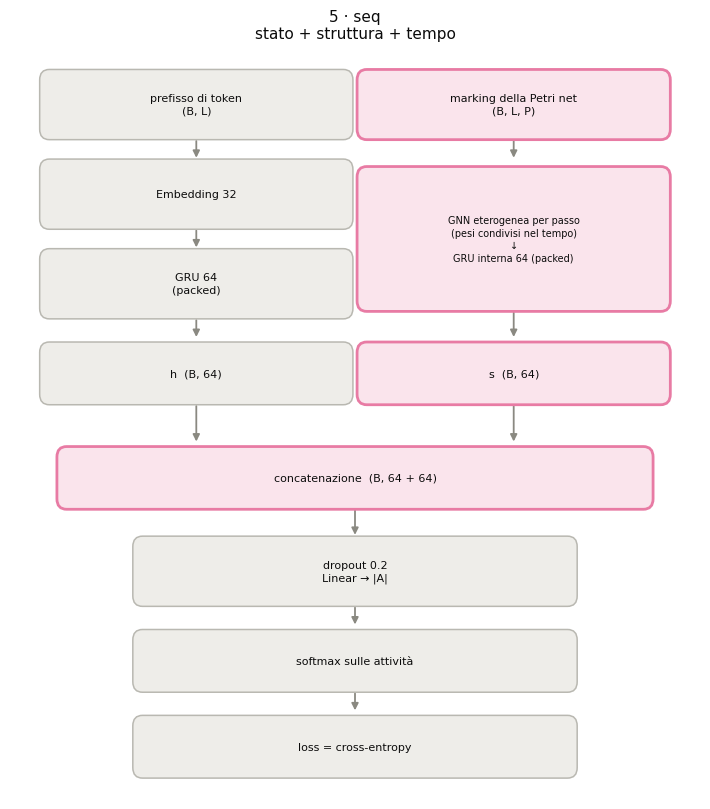

In [4]:
fig = plot_variant_architecture("seq")

## 3. La media sui 10 seed — e perché serve la deviazione accanto

Ogni cella della matrice viene ripetuta con 10 inizializzazioni diverse. La media dice
dove sta il modello; la **deviazione standard fra seed** dice quanto quel numero balla
per motivi che non c'entrano nulla con la conoscenza simbolica.

Questa seconda colonna non è un dettaglio statistico: è **il metro di misura**. Un delta
fra due varianti significa qualcosa solo se è grande rispetto allo spread dei seed. Senza
di essa si finisce per raccontare come scoperta quello che è il rumore
dell'inizializzazione.

In [5]:
celle = cell_means(matrix)
print(f"{len(celle)} celle = 3 dataset x 2 architetture x 5 varianti x 3 noise")
celle.head()

90 celle = 3 dataset x 2 architetture x 5 varianti x 3 noise


,dataset,arch,variant,noise,accuracy_mean,macro_f1_mean,top3_mean,violation_rate_mean,forbidden_mean,accuracy_std,macro_f1_std,top3_std,violation_rate_std,forbidden_std,n_seed
0,Sepsis_Case,gru,baseline,0.00,0.673228,0.486431,0.933256,0.000000,0.002889,0.005707,0.008123,0.003728,0.000000,0.000375,10
1,Sepsis_Case,gru,baseline,0.25,0.672626,0.479310,0.927976,0.000093,0.073988,0.003861,0.005687,0.002694,0.000195,0.001902,10
2,Sepsis_Case,gru,baseline,0.50,0.658962,0.469939,0.911302,0.000417,0.150796,0.007222,0.007488,0.003426,0.000263,0.003850,10
3,Sepsis_Case,gru,checker,0.00,0.672673,0.487167,0.933210,0.000000,0.002118,0.004653,0.005884,0.003526,0.000000,0.000218,10
4,Sepsis_Case,gru,checker,0.25,0.672719,0.479161,0.928439,0.000000,0.052053,0.004184,0.005255,0.003745,0.000000,0.001498,10


In [6]:
# accuratezza media +- spread fra seed, architettura GRU
metric_table(matrix, "accuracy", arch="gru")

variant                                      baseline          checker          marking              gnn              seq
dataset                        noise                                                                                     
Sepsis_Case                    0.00   0.6732 ± 0.0057  0.6727 ± 0.0047  0.6753 ± 0.0028  0.6744 ± 0.0039  0.6741 ± 0.0047
                               0.25   0.6726 ± 0.0039  0.6727 ± 0.0042  0.6763 ± 0.0060  0.6732 ± 0.0012  0.6750 ± 0.0042
                               0.50   0.6590 ± 0.0072  0.6607 ± 0.0062  0.6642 ± 0.0053  0.6631 ± 0.0050  0.6585 ± 0.0078
BPIC_2013_incidents            0.00   0.7190 ± 0.0008  0.7189 ± 0.0016  0.7181 ± 0.0022  0.7180 ± 0.0022  0.7189 ± 0.0012
                               0.25   0.7157 ± 0.0017  0.7157 ± 0.0013  0.7154 ± 0.0057  0.7156 ± 0.0013  0.7145 ± 0.0047
                               0.50   0.7101 ± 0.0109  0.7141 ± 0.0015  0.7103 ± 0.0057  0.7133 ± 0.0030  0.7120 ± 0.0058
BPIC_2020_DomesticDeclarations 0.00   0.8868 ± 0.0003  0.8868 ± 0.0002  0.8868 ± 0.0007  0.8867 ± 0.0004  0.8867 ± 0.0006
                               0.25   0.8854 ± 0.0011  0.8851 ± 0.0012  0.8852 ± 0.0012  0.8852 ± 0.0014  0.8854 ± 0.0012
                               0.50   0.8844 ± 0.0009  0.8840 ± 0.0007  0.8849 ± 0.0013  0.8839 ± 0.0006  0.8845 ± 0.0010

Si legge già a occhio: dentro ogni riga le cinque varianti differiscono alla terza o
quarta cifra decimale, mentre il `±` è dello stesso ordine di grandezza o più grande.
Le prossime sezioni lo verificano in modo sistematico, metrica per metrica.

## 4. Accuracy — chi vince?

Prendere il massimo delle medie darebbe sempre un vincitore, anche quando i modelli sono
indistinguibili. Per questo la tabella riporta, accanto al vincitore:

- `margine` — quanto la media del primo supera quella del secondo;
- `spread` — la deviazione tipica fra seed nella cella;
- `seed vinti` — su quanti dei 10 seed il vincitore batte davvero il secondo,
  **testa a testa a parità di seed**.

L'ultima colonna è quella che decide. Se un modello vince "in media" ma solo su 5 seed su
10, non ha vinto: ha pescato meglio.

In [7]:
winners(matrix, "accuracy").round(4)

,dataset,arch,noise,migliore,valore,secondo,margine,spread,seed vinti,win_rate
0,Sepsis,gru,0.00,3 - marking,0.6753,4 - gnn,0.0009,0.0044,6/10,0.6
1,Sepsis,gru,0.25,3 - marking,0.6763,5 - seq,0.0013,0.0039,7/10,0.7
2,Sepsis,gru,0.50,3 - marking,0.6642,4 - gnn,0.0011,0.0063,7/10,0.7
3,Sepsis,lstm,0.00,1 - baseline,0.6750,2 - checker,0.0002,0.0049,4/10,0.4
4,Sepsis,lstm,0.25,3 - marking,0.6755,1 - baseline,0.0006,0.0052,4/10,0.4
5,Sepsis,lstm,0.50,3 - marking,0.6676,4 - gnn,0.0009,0.0058,5/10,0.5
6,BPIC 2013,gru,0.00,1 - baseline,0.7190,2 - checker,0.0001,0.0016,5/10,0.5
7,BPIC 2013,gru,0.25,2 - checker,0.7157,1 - baseline,0.0000,0.0030,5/10,0.5
8,BPIC 2013,gru,0.50,2 - checker,0.7141,4 - gnn,0.0009,0.0054,5/10,0.5
9,BPIC 2013,lstm,0.00,5 - seq,0.7187,1 - baseline,0.0006,0.0013,6/10,0.6


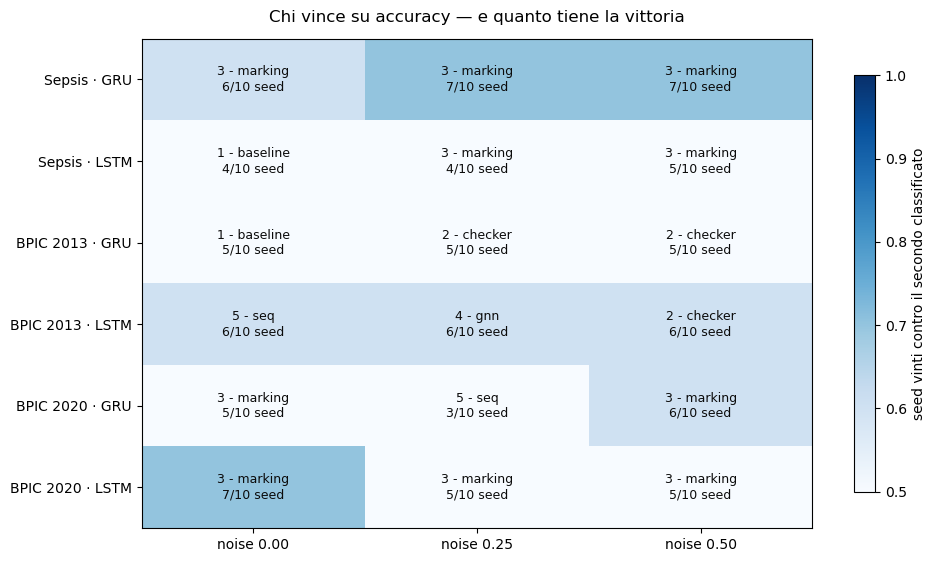

In [8]:
fig = plot_winner_reliability(matrix, "accuracy")

**Lettura.** Il vincitore cambia da cella a cella — `marking`, `baseline`, `checker`,
`gnn`, `seq` compaiono tutti — e le vittorie stanno fra 3 e 7 seed su 10. Ci sono celle in
cui il modello con la media più alta perde il confronto diretto sulla maggioranza dei
seed: è la definizione operativa di pareggio.

Il grafico sotto guarda la stessa cosa senza passare dalle classifiche: la differenza di
accuratezza di ogni variante rispetto alla baseline, **appaiata per seed** (i due modelli
sottratti condividono inizializzazione e ordine dei batch, così la varianza comune si
cancella). Ogni pallino è un seed, il rombo è la media.

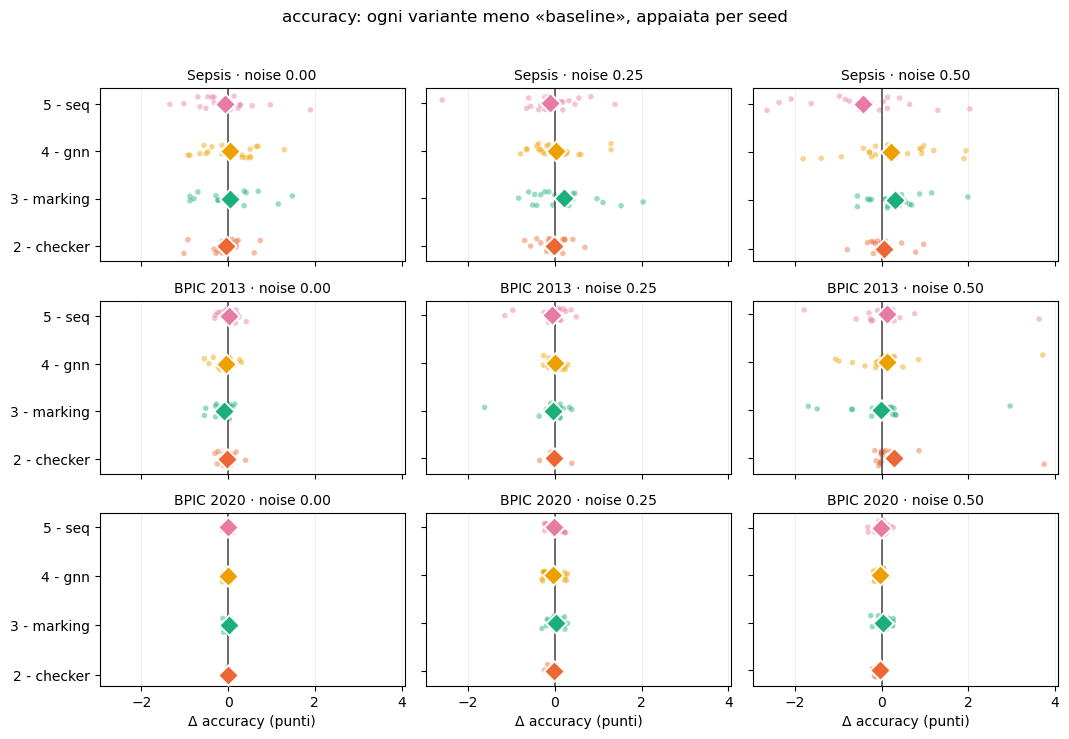

In [9]:
fig = plot_paired_deltas(matrix, "accuracy")

Le nuvole sono centrate sullo zero in tutti e nove i pannelli. Nessuna variante si sposta
da una parte, a nessun livello di noise, su nessun dataset — e la scala dell'asse è la
stessa ovunque, quindi il confronto fra pannelli è onesto: su BPIC 2020 le nuvole sono
strette perché il dataset è facile e stabile, non perché lì l'effetto sia più piccolo.

> **Risposta 1 — accuracy: nessuno vince.** Né il vincolo nella loss, né lo stato, né la
> struttura, né la storia spostano la predizione.

## 5. Violation rate — la metrica che non si muove

Qui la risposta non è una classifica, è un numero solo: su tutte e 900 le run l'argmax
del modello quasi mai propone un'attività vietata.

In [10]:
vr = matrix["violation_rate"]
print(f"media          {vr.mean():.6f}")
print(f"massimo        {vr.max():.6f}   (su 900 run)")
print(f"run a zero     {(vr == 0).sum()} / {len(vr)}")
print()
print(matrix.groupby(['dataset', 'noise'], observed=True)['violation_rate'].mean().round(6))

media          0.000083
massimo        0.003170   (su 900 run)
run a zero     780 / 900

dataset                         noise
Sepsis_Case                     0.00     0.000000
                                0.25     0.000139
                                0.50     0.000495
BPIC_2013_incidents             0.00     0.000000
                                0.25     0.000000
                                0.50     0.000000
BPIC_2020_DomesticDeclarations  0.00     0.000000
                                0.25     0.000013
                                0.50     0.000097
Name: violation_rate, dtype: float64


Un grafico di questi valori sarebbe fuorviante: mostrerebbe differenze fra numeri che
sono tutti zero entro il rumore. Il fatto interessante è il valore in sé, e va detto a
parole.

**Perché è ~0 anche senza logica.** I vincoli minati dal log sono *ridondanti* rispetto a
ciò che l'RNN impara comunque dai dati: la sequenza di attività è già così regolare che il
modello non ha bisogno del simbolico per rispettarla nella sua scelta finale. Questo è il
motivo per cui la logica ha così poco spazio per aiutare — e vale anche per la logic loss
di T-LEAF, che spinge su un segnale già soddisfatto.

Il danno del label noise, quindi, non si vede nell'argmax: si vede **nella distribuzione**.
Ed è lì che va cercato l'effetto della conoscenza — nella prossima metrica.

> **Risposta 2 — violation rate: pareggio a zero**, per tutti, a ogni livello di noise.

## 6. Forbidden mass — l'unica metrica dove qualcosa succede

`forbidden` misura quanta probabilità il modello mette *complessivamente* sulle attività
che il processo vieta nello stato corrente. Non guarda solo la scelta finale, quindi
registra anche un modello che "ci pensa" senza poi sbagliare.

In [11]:
winners(matrix, "forbidden").round(4)

,dataset,arch,noise,migliore,valore,secondo,margine,spread,seed vinti,win_rate
0,Sepsis,gru,0.00,2 - checker,0.0021,3 - marking,0.0004,0.0003,9/10,0.9
1,Sepsis,gru,0.25,2 - checker,0.0521,5 - seq,0.0202,0.0024,10/10,1.0
2,Sepsis,gru,0.50,2 - checker,0.1099,5 - seq,0.0387,0.0042,10/10,1.0
3,Sepsis,lstm,0.00,2 - checker,0.0025,5 - seq,0.0004,0.0003,10/10,1.0
4,Sepsis,lstm,0.25,2 - checker,0.0533,4 - gnn,0.0204,0.0031,10/10,1.0
5,Sepsis,lstm,0.50,2 - checker,0.1095,5 - seq,0.0394,0.0044,10/10,1.0
6,BPIC 2013,gru,0.00,2 - checker,0.0000,1 - baseline,0.0000,0.0000,9/10,0.9
7,BPIC 2013,gru,0.25,2 - checker,0.0435,5 - seq,0.0183,0.0046,10/10,1.0
8,BPIC 2013,gru,0.50,2 - checker,0.0922,3 - marking,0.0366,0.0056,10/10,1.0
9,BPIC 2013,lstm,0.00,2 - checker,0.0000,5 - seq,0.0000,0.0000,8/10,0.8


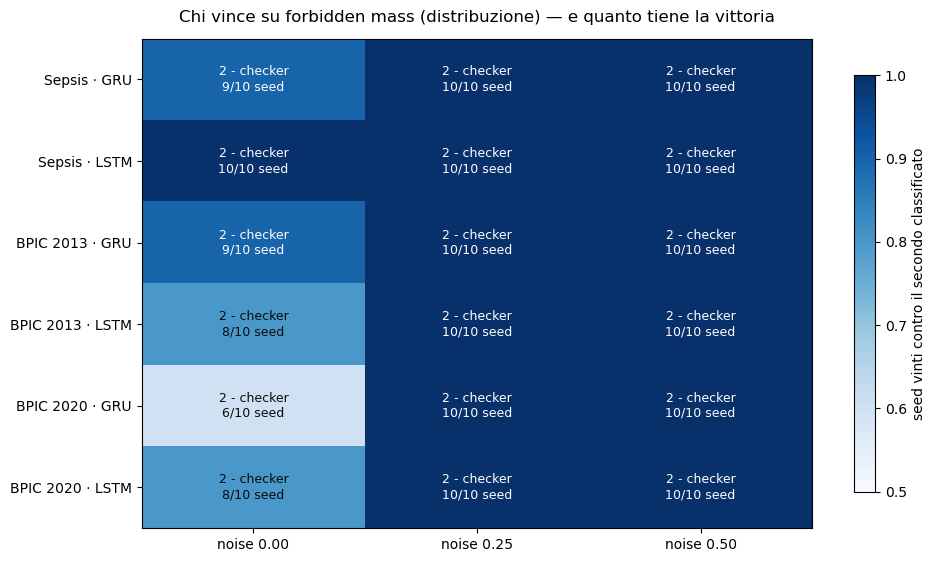

In [12]:
fig = plot_winner_reliability(matrix, "forbidden")

**18 celle su 18, e nelle 12 celle con noise 10 seed su 10.** Confronta questa figura con
quella della sezione 4: stessa griglia, stesso metodo, risultato opposto. Non è che i
nostri esperimenti non sappiano distinguere niente — sanno distinguere benissimo, quando
c'è qualcosa da distinguere.

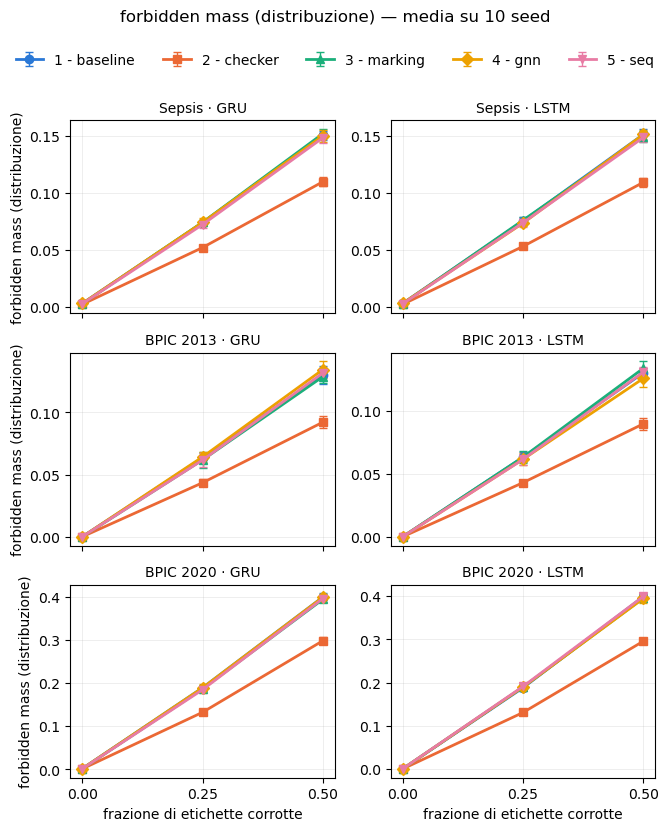

In [13]:
fig = plot_metric_by_noise(matrix, "forbidden")

La riga arancione (`checker`) si stacca in tutti e sei i pannelli. Le altre quattro sono
sovrapposte: **le varianti che ricevono la conoscenza come feature si comportano come la
baseline**, anche quando la feature è ricca come una sequenza di marking.

Quanto vale il distacco, in percentuale sulla baseline:

In [14]:
relative_change(matrix, "forbidden").round(1)

variant                               checker  marking   gnn   seq
dataset                        noise                              
Sepsis_Case                    0.00     -26.4    -11.6   2.0 -11.9
                               0.25     -29.6      0.6  -1.2  -2.2
                               0.50     -27.4     -0.2  -0.2  -1.6
BPIC_2013_incidents            0.00     -30.6      7.2  19.0  17.9
                               0.25     -31.8     -1.3  -0.8  -2.9
                               0.50     -30.2      0.8  -0.1   0.8
BPIC_2020_DomesticDeclarations 0.00     -30.3    -14.1   5.5  -7.8
                               0.25     -30.3     -0.2   0.4  -0.4
                               0.50     -25.6     -1.1  -0.6  -0.4

Il `checker` toglie **fra il 26% e il 32%** della massa vietata in tutte e nove le
combinazioni dataset × noise, senza una sola eccezione. Le tre varianti *feature* restano
entro pochi punti percentuali dalla baseline, e sui dati puliti il segno del loro scarto
cambia da dataset a dataset — cioè è rumore.

E questo guadagno **non si paga**: nella sezione 4 il `checker` è indistinguibile dalla
baseline in accuratezza. È l'unico effetto positivo, riproducibile e gratuito di tutta la
tesi.

> **Risposta 3 — forbidden mass: vince il `checker`, ovunque.** La conoscenza di processo
> funziona quando entra come **loss**, non come **feature**.

## 7. Sintesi

| metrica | migliore | quanto tiene | lettura |
|---|---|---|---|
| accuracy | nessuno (il vincitore cambia cella per cella) | 3–7 seed su 10 | pareggio: la conoscenza non aiuta a predire |
| violation rate | tutti, a ~0 | — | i vincoli sono ridondanti rispetto a ciò che l'RNN impara da sola |
| forbidden mass | **checker** (loss simbolica) | **18/18 celle, 10/10 seed sotto noise** | −26/−32%, a costo predittivo nullo |

**La tesi in una riga: feature simbolica ≠ loss simbolica.** Non sono due modi equivalenti
di dare al modello la stessa informazione. Iniettare lo stato del processo come input non
cambia niente — e la scala di ablazione mostra che non è per mancanza di sofisticazione,
perché aggiungere la struttura del grafo e poi la storia temporale non sposta il
risultato. Usare lo stesso vincolo per *penalizzare* il modello durante il training, invece,
funziona: in modo piccolo, ma perfettamente regolare.

### Cosa questa matrice non contiene, e va detto

- **L'embedder T-LEAF** è escluso per costo (15–30× il tempo di training per cella): il suo
  verdetto viene dal grid a seed singolo `runs/benchmark_corruption.csv`, dove è instabile
  e dannoso. Va citato come risultato a seed singolo, non come parte di questa matrice.
- **Il masking duro** (`baseline_mask`) non è qui: azzera la forbidden mass *per
  costruzione*, gratis, senza allenare niente. Sul piano pratico domina il checker; ciò che
  resta al checker è l'argomento qualitativo — la maschera non retropropaga, il checker
  forma una distribuzione migliore.
- **Il risultato negativo è delimitato, non universale**: vale per questi tre log, per il
  next-activity, con Petri net minate col miner inductive. Il meccanismo (il marking è
  funzione deterministica del prefisso, e collassa a ~6 stati distinti su 14 eventi) è
  discusso nei finding F7–F9 del `docs/JOURNAL.md`.